Data Preview:
   event        date       country      city  \
0  click  2021-08-21  Saudi Arabia    Jeddah   
1  click  2021-08-21  Saudi Arabia    Jeddah   
2  click  2021-08-21         India  Ludhiana   
3  click  2021-08-21        France   Unknown   
4  click  2021-08-21      Maldives      Malé   

                              artist          album          track  \
0                             Tesher    Jalebi Baby    Jalebi Baby   
1                             Tesher    Jalebi Baby    Jalebi Baby   
2                      Reyanna Maria      So Pretty      So Pretty   
3  Simone & Simaria, Sebastian Yatra  No Llores Más  No Llores Más   
4                             Tesher    Jalebi Baby    Jalebi Baby   

           isrc                                linkid  
0  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
1  QZNWQ2070741  2d896d31-97b6-4869-967b-1c5fb9cd4bb8  
2  USUM72100871  23199824-9cf5-4b98-942a-34965c3b0cc2  
3  BRUM72003904  35573248-4e49-47c7-af80-08a960fa74c

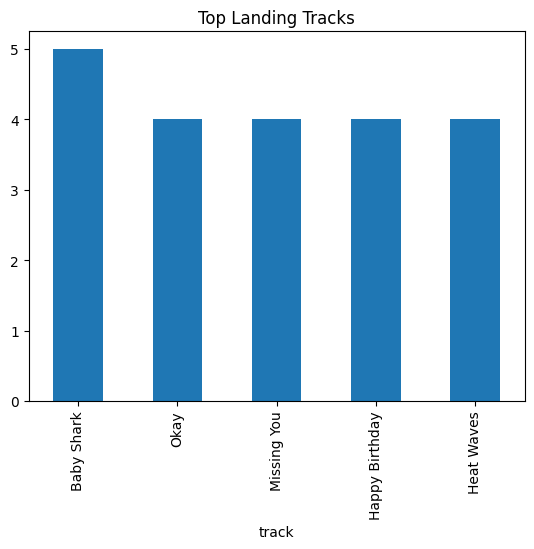


Top Exit Tracks:
 track
Baby Shark        5
Okay              4
Missing You       4
Happy Birthday    4
Heat Waves        4
Name: count, dtype: int64


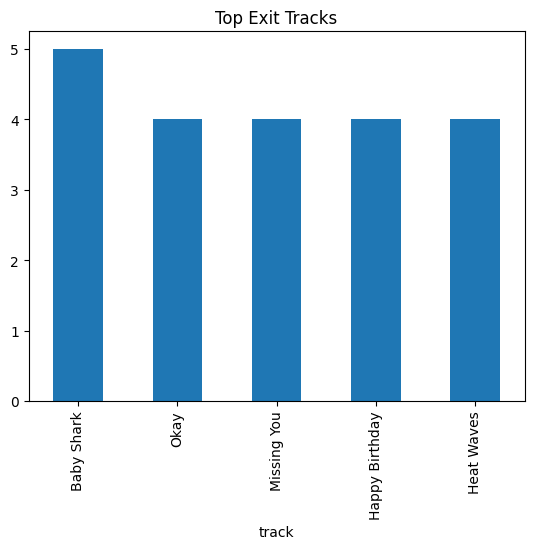


Top Countries:
 country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Name: count, dtype: int64


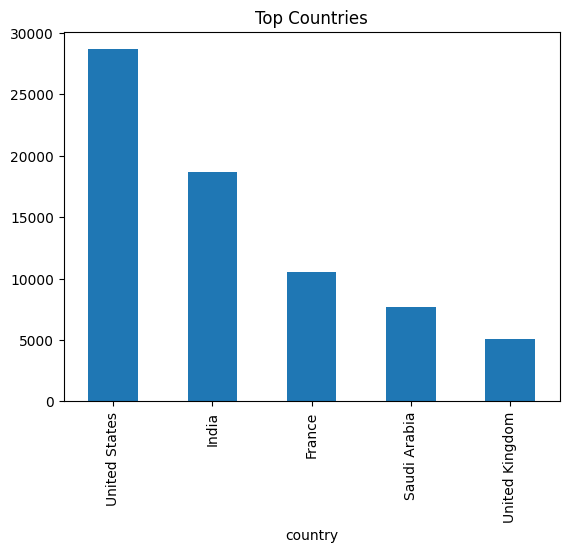


Top Artists:
 artist
Tesher            8288
Anne-Marie        4029
Tundra Beats      3951
Roddy Ricch       3107
Olivia Rodrigo    3037
Name: count, dtype: int64


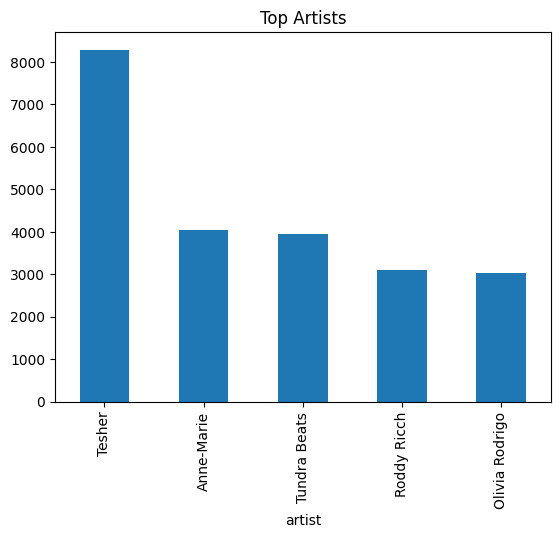


User Flow Sample:
                                track                         next_track  count
0                              "BOP"                              "BOP"      4
1                 #BrooklynBloodPop!                 #BrooklynBloodPop!      3
2  $lide (feat. Lul Lik & O$b $Moke)  $lide (feat. Lul Lik & O$b $Moke)      2
3               (She's) Just a Phase               (She's) Just a Phase      1
4                                  .                                  .      2

Avg Actions per Session: 31.92680385517062


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset
df = pd.read_csv("traffic.csv")

print("Data Preview:")
print(df.head())

# ================================
# 3. Data Cleaning
# ================================
df = df.drop_duplicates()

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Fill missing values
df = df.fillna("Unknown")

# ================================
# 4. Create Session ID
# (using linkid as session)
# ================================
df['session'] = df['linkid']

# ================================
# 5. Basic Metrics
# ================================

# Total Users (approx using city+country)
df['user'] = df['city'] + "_" + df['country']
total_users = df['user'].nunique()

# Total Sessions
total_sessions = df['session'].nunique()

print("\nTotal Users:", total_users)
print("Total Sessions:", total_sessions)

# ================================
# 6. Bounce Rate
# ================================
session_counts = df.groupby('session')['track'].count()

bounce_sessions = session_counts[session_counts == 1].count()
bounce_rate = (bounce_sessions / total_sessions) * 100

print("Bounce Rate:", bounce_rate)

# ================================
# 7. Top Landing Pages (Tracks)
# ================================
landing = df.groupby('session').first()

top_landing = landing['track'].value_counts().head(5)
print("\nTop Landing Tracks:\n", top_landing)

top_landing.plot(kind='bar', title="Top Landing Tracks")
plt.show()

# ================================
# 8. Top Exit Pages (Tracks)
# ================================
exit_page = df.groupby('session').last()

top_exit = exit_page['track'].value_counts().head(5)
print("\nTop Exit Tracks:\n", top_exit)

top_exit.plot(kind='bar', title="Top Exit Tracks")
plt.show()

# ================================
# 9. Top Countries (Traffic Source)
# ================================
top_country = df['country'].value_counts().head(5)

print("\nTop Countries:\n", top_country)

top_country.plot(kind='bar', title="Top Countries")
plt.show()

# ================================
# 10. Top Artists
# ================================
top_artist = df['artist'].value_counts().head(5)

print("\nTop Artists:\n", top_artist)

top_artist.plot(kind='bar', title="Top Artists")
plt.show()

# ================================
# 11. Simple User Flow
# ================================
df = df.sort_values(['session', 'date'])

df['next_track'] = df.groupby('session')['track'].shift(-1)

flow = df.groupby(['track', 'next_track']).size().reset_index(name='count')

print("\nUser Flow Sample:\n", flow.head())

# ================================
# 12. Average Actions per Session
# ================================
avg_actions = session_counts.mean()
print("\nAvg Actions per Session:", avg_actions)